# **Deus Ex Machina - Project CS4**
## **(De)Generative AI**

### Group Members

- Catarina Monteiro
- Diogo Mendes
- Gonçalo Brochado
- Guilherme Vaz
- Matheus Bissacot

## **Brief Introduction**

The case study presented in the article "Generative AI Bias: A Growing Concern in the Industry" by Bloomberg examines the biases inherent in generative AI models, particularly focusing on Stable Diffusion. It highlights how these models often misrepresent racial and gender demographics in their outputs, perpetuating harmful stereotypes. In this notebook, we will present a step-by-step tutorial about how to avoid these serious issues using an example and applying various methodologies to handle imbalanced data.

## **Libraries**

The libraries that were used in these projects are:

- _pandas_ for manipulating datasets | **(Version 2.2.3)**
- _seaborn_ and _matplotlib_ for plot analysis | **(Version 0.13.2)**
- _sklearn_ for preprocessing data, applying algorithms and measuring test results | **(Version 1.5.2)**
- _xgboost_ for applying the XGBoost algorithm | **(Version 2.1.2)**
- _imblearn_ for applying the balance techniques | **(Version 0.12.4)**
- _Python_ | **(version 3.11.7)**
- _dataprep_ | **(version COLOCAR VERSÃO)**
- _plotly_ | **(version 5.24.1)**

In [105]:
# ! pip install -U dataprep

In [106]:
# ! pip install plotly

In [107]:
import pandas as pd
import seaborn as sns
import numpy as np
from math import pi
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from imblearn.pipeline import Pipeline, make_pipeline
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, average_precision_score
# from dataprep.eda import create_report
import plotly.express as px

## **Dataset Overview**

The [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download) dataset under review consists of credit card transactions made by European cardholders in September 2013, encompassing a total of 284,807 transactions, of which 492 are identified as fraudulent. 

This results in a highly unbalanced dataset, with fraud cases representing only 0.172% of all transactions. The dataset features numerical input variables derived from a Principal Component Analysis (PCA) transformation, with the original features not disclosed due to confidentiality concerns. The variables include 28 principal components (V1 to V28), along with two untransformed features: 'Time,' which indicates the seconds elapsed since the first transaction, and 'Amount,' representing the transaction value. 

The response variable, 'Class,' indicates fraud (1) or non-fraud (0). Given the significant class imbalance, it is recommended to evaluate model performance using the Area Under the Precision-Recall Curve (AUPRC) rather than traditional accuracy metrics, as confusion matrix accuracy may not provide meaningful insights in such scenarios. 

This dataset was collected and analyzed as part of a research collaboration between Worldline and the Machine Learning Group at ULB (Université Libre de Bruxelles) focused on big data mining and fraud detection.

In [108]:
df_credit = pd.read_csv("creditcard.csv") # Load the dataset

The first steps are doing the basic analysis: how the dataset is composed, what are the relevant attributes and, in general, try to understand it better. Although simple, it is a crucial step, because after doing this, we understand what changes can be made to improve this dataset.

In [109]:
df_credit.head() # Show the first 5 rows of the dataset

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [110]:
print("Shape of the dataset (rows, columns):", df_credit.shape) # Displaying the shape of the dataset

Shape of the dataset (rows, columns): (284807, 31)


The dataset contains **284,807 rows** and **31 columns**. It presents transactions that occurred in two days, where we have **492 frauds** out of **284,807 transactions**. 

In [111]:
df_credit.describe() # Displaying the summary statistics of the dataset

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [112]:
df_credit.info() # Displaying the information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

The dataset consists of 284,807 records and 31 columns, with features primarily derived using Principal Component Analysis (PCA). The Time column captures the elapsed time since the first transaction, ranging from 0 to 172,792 seconds, with a mean of 94,814 seconds.

The PCA-transformed features (V1–V28) exhibit a mean close to zero and varying standard deviations, reflecting their normalization. The Amount column, representing transaction values, has a mean of 88.35 and a maximum of 25,691.16, indicating a highly skewed distribution. The target variable, Class, is binary, with a mean of 0.0017, highlighting the dataset's significant class imbalance.

In [113]:
# Checking for missing values
print("Missing values per column:")
display(df_credit.isnull().sum())

Missing values per column:


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [114]:
print("Number of duplicate rows:", df_credit.duplicated().sum()) # Checking for duplicate rows

Number of duplicate rows: 1081


There are **no missing values**, but there are **1081 duplicate rows**. The existance of duplicated rows is not problematic, once there could be two equal transactions.

In [115]:
# Checking for the data types of each column
print("Data types of each column:")
display(df_credit.dtypes)

Data types of each column:


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

The features are all float64 besides the class column, which is int64

In [116]:
df_credit['Class'].value_counts() # Checking the distribution of the target variable

Class
0    284315
1       492
Name: count, dtype: int64

The dataset is highly imbalanced, with 284,315 records labeled as class `0` (non-fraudulent) and only 492 labeled as class `1` (fraudulent). This imbalance emphasizes the need for specialized techniques to effectively handle and analyze the minority class.

## **Data Visualization**

### **Class Distribution**

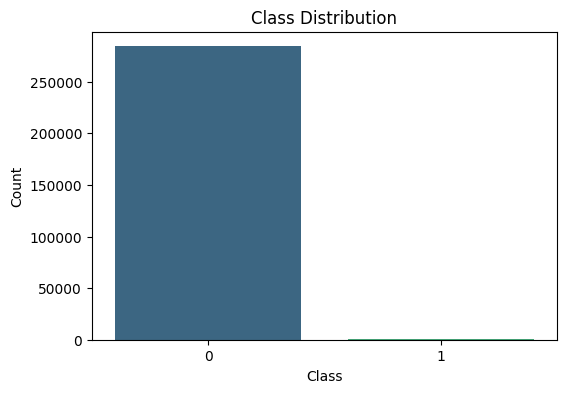

In [117]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_credit, x='Class', hue='Class', dodge=False, palette="viridis")
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend([], [], frameon=False) 
plt.show()

The dataset is highly imbalanced, with an overwhelming majority of transactions being non-fraudulent. The count of non-fraudulent transactions (class 0) is in the range of hundreds of thousands, while fraudulent transactions (class 1) are nearly negligible in comparison, barely visible on the chart. This imbalance is typical for fraud detection datasets, as fraudulent activities represent a small fraction of all transactions. While this imbalance reflects real-world scenarios, it poses challenges for machine learning models, which may struggle to accurately identify the minority class.

### **Time and Amount Distribution**

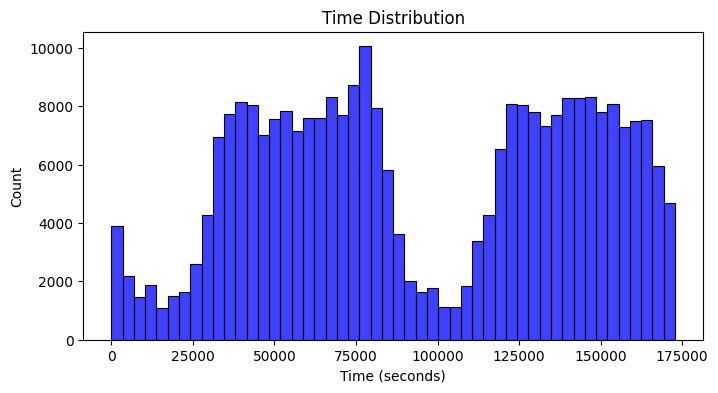

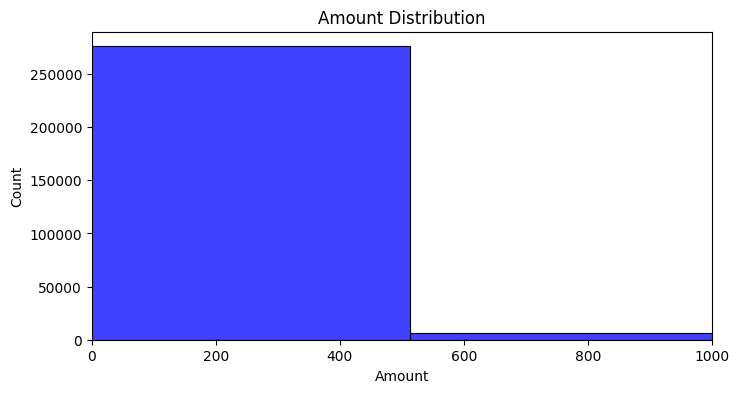

In [118]:
plt.figure(figsize=(8,4))
sns.histplot(df_credit['Time'], bins=50, kde=False, color='blue')
plt.title('Time Distribution')
plt.xlabel('Time (seconds)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df_credit['Amount'], bins=50, kde=False, color='blue')
plt.title('Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.xlim([0, 1000]) 
plt.show()

### **Correlation Heatmap**

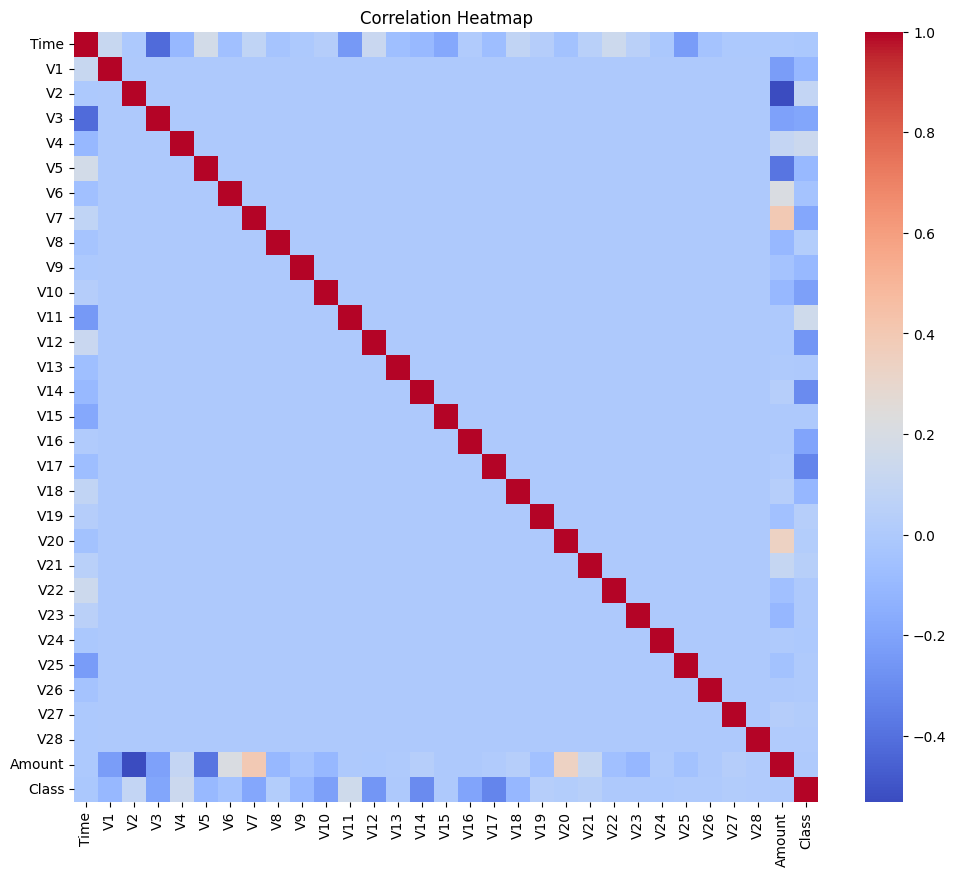

In [119]:
plt.figure(figsize=(12,10))
correlation = df_credit.corr()
sns.heatmap(correlation, cmap="coolwarm", annot=False, cbar=True)
plt.title('Correlation Heatmap')
plt.show()

Most of the features (V1 to V28) exhibit weak correlations with each other and with the target variable, as indicated by the predominantly light blue coloration. This suggests that these features are largely independent, which aligns with the fact that they result from a dimensionality reduction technique like PCA. Interestingly, a few features, such as "Amount" and others close to "Class," show slightly stronger correlations with the target variable, though still not very pronounced.

### **PCA Component Dsitribution (V1-V28)**

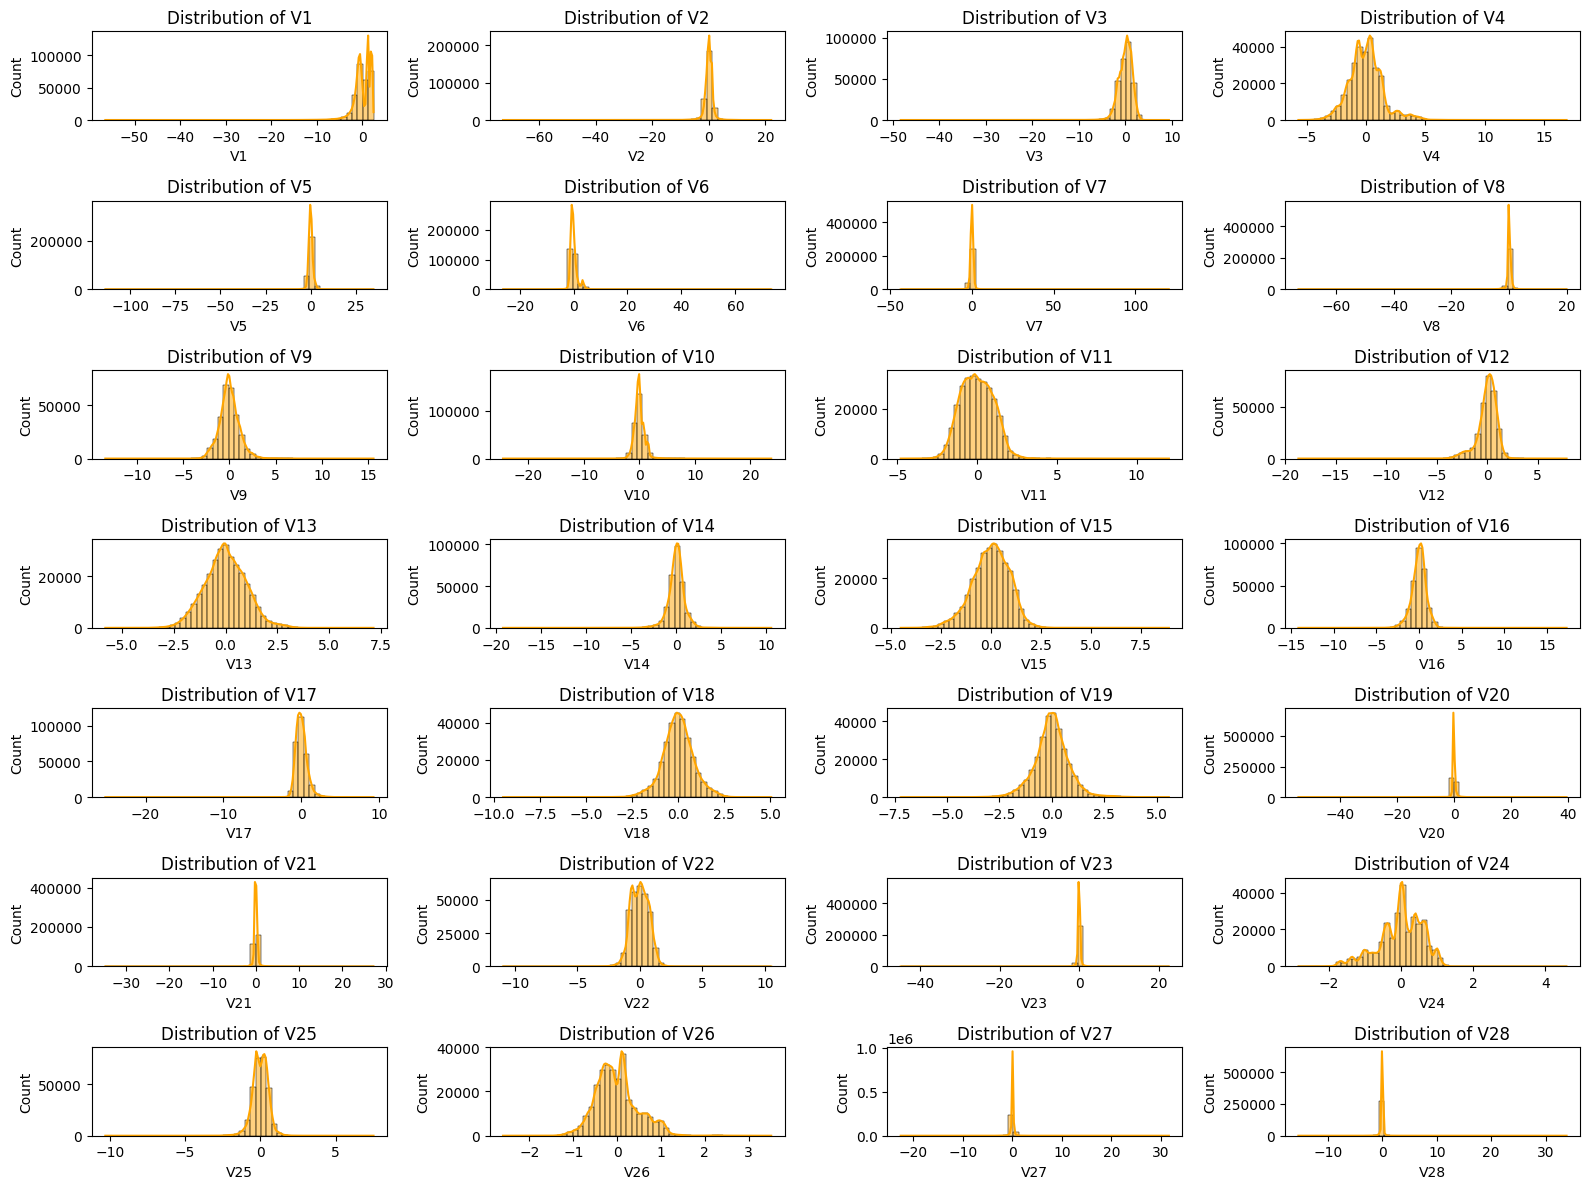

In [120]:
plt.figure(figsize=(16,12))
for i, col in enumerate(df_credit.columns[1:29], 1):  
    plt.subplot(7, 4, i)
    sns.histplot(df_credit[col], bins=50, kde=True, color='orange')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Most of these features appear to follow approximately Gaussian or normal-like distributions, with their values concentrated around a central peak and tapering off symmetrically. Some features, such as V1, V2, V3, and V23, have distributions that exhibit long tails or skewness, indicating potential outliers or asymmetrical data. Features like V27 and V28 show extremely sharp peaks, suggesting that most data points are clustered closely around a narrow range of values. These distributions are the result of PCA transformations applied to anonymize the data, which compresses the original feature relationships into orthogonal components. The overall shape of these distributions highlights the variability across different features.

### **Amount By Class**

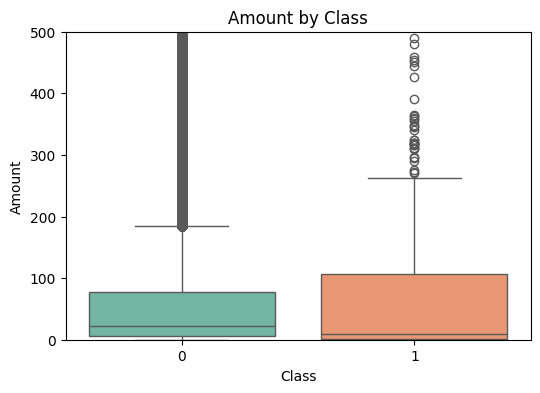

In [121]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_credit, x='Class', y='Amount', hue='Class', dodge=False, palette="Set2")
plt.title('Amount by Class')
plt.ylim([0, 500]) 
plt.xlabel('Class')
plt.ylabel('Amount')
plt.legend([], [], frameon=False) 
plt.show()

For non-fraudulent transactions (Class 0), the distribution shows a median transaction amount close to zero and a relatively small interquartile range (IQR), but with the presence of significant outliers extending up to 500. In contrast, fraudulent transactions (Class 1) exhibit a higher median amount and a larger IQR, indicating more variability in transaction amounts for this class. The presence of numerous outliers in Class 1 suggests that fraudulent transactions often involve unusually high amounts, reinforcing the importance of amount as a distinguishing feature in fraud detection. However, the overlap and variability between the two classes imply that transaction amount alone cannot reliably separate fraud from non-fraud and must be used in conjunction with other features.

### **Dataprep Report**

In [122]:
# create_report(df_credit).show_browser() # Generate an EDA report NÃO CONSIGO INSTALAR O DATAPREP, QUEM CONSEGUIR, CORRA ISTO

## **Performance Metrics and Classification Algorithms**

**Precision** measures the proportion of correctly identified positive cases (e.g., fraud) out of all cases predicted as positive. A high precision indicates that the model is effective at minimizing false positives, meaning that when the model flags a transaction as fraudulent, it is likely correct. Precision is particularly important in applications where falsely identifying a legitimate transaction as fraudulent can lead to customer dissatisfaction and unnecessary intervention, such as blocking accounts or transactions.

**Recall**, or the True Positive Rate, focuses on the ability of the model to correctly identify all actual positive cases. It represents the proportion of fraud cases that are successfully detected. High recall is critical in fraud detection because missing fraudulent transactions (false negatives) can lead to financial losses and reputational damage. Prioritizing recall ensures that most fraud cases are caught, even if it comes at the expense of a higher false-positive rate.

The **F1 Score** is the harmonic mean of precision and recall, balancing these two metrics into a single measure. It is especially useful in situations with imbalanced datasets, as it accounts for both false positives and false negatives. The F1 score is important when a tradeoff is needed between precision (minimizing false alarms) and recall (catching all fraud cases). A high F1 score indicates that the model performs well in identifying fraud while keeping false positives under control.

**Accuracy** measures the overall correctness of the model by calculating the proportion of correctly classified instances (both positive and negative) out of all predictions. While accuracy is a straightforward metric, it is less useful in imbalanced datasets, as it can be misleading. For instance, in a dataset with only 1% fraud cases, a model that predicts every transaction as legitimate could achieve 99% accuracy but fail to detect any fraud.

Finally, **AUPRCC** (Area Under the Precision-Recall Curve) is a metric specifically designed for imbalanced datasets. It evaluates the tradeoff between precision and recall across various thresholds. A high AUPRCC score indicates that the model performs consistently well at distinguishing between positive and negative cases. This metric is particularly important in cases like fraud detection, where precision and recall are often at odds, and finding an optimal threshold for classification is critical.

Each of these metrics serves a specific purpose, with precision and recall often being the most crucial for imbalanced problems like this one. Together with F1 Score and AUPRCC, they provide a comprehensive understanding of the model’s performance, ensuring that both false positives and false negatives are carefully managed.

##### **Random Forest**
This is an Ensemble learning method that uses the bagging technique. Basically, it builds multiple decision trees from different subsets of the data, created using bootstrapping (sampling with replacement). Then, each tree makes a prediction, and the final output is determined by the majority voting, i.e the class most predicted by the trees. Finally, it randomly selects a subset of features at each split to reduce correlation between trees.

We chose these algorithm because it is robust to imbalanced data, have adjustable class weights, feature importance and easy-to-implement sampling strategies. Because of these aspects, this algorithm are widely used for researches similar to our case study and get very good results.

##### **XGBoost**
Also known as Extreme Gradient Boosting, this is a Gradient boosting framework. It sequentially builds decision trees, where each tree corrects the errors of the previous ones, and, at each step, minimizes a loss function (e.g., log loss for classification) by learning from the residuals. Then, regularization (L1/L2) is applied to control overfitting and, finally, combines the outputs of all trees to make predictions.

Although XGBoost doesn't get the same great results as Random Forest, they are still reliable enough to be picked. But the most important aspect for picking this algorithm definitely is to see how the changes and balance techniques can affect this.

### **Split the Dataset**

In [123]:
X = df_credit.drop('Class', axis=1)
y = df_credit['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### **Random Forest**

In [124]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42) # Random Forest Classifier

In [125]:
model_rf.fit(X_train, y_train) # Fitting the model

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [126]:
y_pred = model_rf.predict(X_test) # Predictions

cm_standard_rf = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_standard_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Default'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_standard_rf = pd.DataFrame(data)
print(df_standard_rf)

[[85291     4]
 [   36   112]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest   Default   0.965517  0.756757  0.848485  0.999532  0.731083


### **XGBoost**

In [127]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])) # XGBoost Classifier

In [128]:
model_xgb.fit(X_train, y_train) # Fitting the model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [129]:
y_pred = model_xgb.predict(X_test) # Predictions

cm_standard_xgb = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_standard_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Default'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_standard_xgb = pd.DataFrame(data)
print(df_standard_xgb)

[[85279    16]
 [   31   117]]

     Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost   Default   0.879699  0.790541   0.83274   0.99945  0.695801


## **Balancing Techniques**

Balancing techniques are methods used to address class imbalance in datasets, ensuring that the minority class is adequately represented during model training. These techniques include oversampling (e.g., SMOTE, ADASYN), undersampling (e.g., Tomek Links, Edited Nearest Neighbors), and hybrid approaches that combine both strategies. The goal of balancing is to improve the model's ability to learn patterns for the minority class, reducing bias and improving classification performance across all classes.

For each balanced dataset, a Random Forest (RF) and a XGBoost will be trained. This methodology ensures a thorough evaluation of how each balancing technique impacts the performance of RF and XGBoost, leveraging their strengths in ensemble learning and gradient boosting, respectively. The results will highlight the effectiveness of the balancing strategies and the predictive capabilities of the models under imbalanced conditions.

### **Random Oversampling**

Random Oversampling involves randomly duplicating instances from the minority class. Because it involves creating exact duplicates of the minority class examples, it can raise the risk of overfitting. For instance, if each data point from the minority class is replicated six times before the dataset is split, then during a 3-fold cross-validation, each fold would, on average, contain two copies of each minority class point. This situation can lead a classifier to develop rules that seem accurate but are actually based on just one of the replicated examples. As a result, the model may perform well on the training data but fail to generalize effectively to unseen data.

In [130]:
over = RandomOverSampler(random_state=42) # Random Over Sampling

In [131]:
X_over, y_over = over.fit_resample(X_train, y_train) # Fitting the model

In [132]:
# Displaying the distribution of the target variable after over sampling
print('0: ' + str(y_over.value_counts()[0]))
print('1: ' + str(y_over.value_counts()[1]))

0: 199020
1: 199020


In [133]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42) # Random Forest Classifier
model_rf.fit(X_over, y_over) # Fitting the model

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [134]:
y_pred = model_rf.predict(X_test) # Predictions

cm_ro_rf = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_ro_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Random Oversampling'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_ro_rf = pd.DataFrame(data)
print(df_ro_rf)

[[85291     4]
 [   38   110]]

          Model            Technique  Precision    Recall  F1 Score  Accuracy  \
0  RandomForest  Random Oversampling   0.964912  0.743243  0.839695  0.999508   

     AUPRCC  
0  0.717609  


In [135]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_over[y_over == 0]) / len(y_over[y_over == 1])) # XGBoost Classifier
model_xgb.fit(X_over, y_over) # Fitting the model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [136]:
y_pred = model_xgb.predict(X_test) # Predictions

cm_ro_xgb = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_ro_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Random Oversampling'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_ro_xgb = pd.DataFrame(data)
print(df_ro_xgb)

[[85283    12]
 [   32   116]]

     Model            Technique  Precision    Recall  F1 Score  Accuracy  \
0  XGBoost  Random Oversampling    0.90625  0.783784   0.84058  0.999485   

     AUPRCC  
0  0.710679  


### **Random Undersampling**

This entails the random selection and removal of examples from the majority class in the training dataset. This method can be particularly effective for datasets with class imbalances, especially when there are enough examples in the minority class to build a reliable model. By reducing the number of majority class instances, random undersampling helps to balance the class distribution, which can enhance the model's ability to learn from the minority class without being overwhelmed by the majority class data.

In [137]:
under = RandomUnderSampler(random_state=42) # Random Under Sampling

In [138]:
X_under, y_under = under.fit_resample(X_train, y_train) # Fitting the model

In [139]:
# Displaying the distribution of the target variable after under sampling
print('0: ' + str(y_under.value_counts()[0]))
print('1: ' + str(y_under.value_counts()[1]))

0: 344
1: 344


In [140]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42) # Random Forest Classifier
model_rf.fit(X_under, y_under) # Fitting the model

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [141]:
y_pred = model_rf.predict(X_test) # Predictions

cm_ru_rf = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_ru_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Random Undersampling'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_ru_rf = pd.DataFrame(data)
print(df_ru_rf)

[[83404  1891]
 [   18   130]]

          Model             Technique  Precision    Recall  F1 Score  \
0  RandomForest  Random Undersampling   0.064325  0.878378  0.119871   

   Accuracy    AUPRCC  
0  0.977658  0.056712  


In [142]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_under[y_under == 0]) / len(y_under[y_under == 1])) # XGBoost Classifier
model_xgb.fit(X_under, y_under) # Fitting the model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [143]:
y_pred = model_xgb.predict(X_test) # Predictions

cm_ru_xgb = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_ru_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Random Undersampling'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_ru_xgb = pd.DataFrame(data)
print(df_ru_xgb)

[[82239  3056]
 [   14   134]]

     Model             Technique  Precision    Recall  F1 Score  Accuracy  \
0  XGBoost  Random Undersampling   0.042006  0.905405  0.080288   0.96407   

     AUPRCC  
0  0.038197  


### **Class Weights**

In [144]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42, class_weight="balanced") # Random Forest Classifier
model_rf.fit(X_train, y_train) # Fitting the model

RandomForestClassifier(class_weight='balanced', n_estimators=50, n_jobs=-1,
                       random_state=42)

In [145]:
y_pred = model_rf.predict(X_test) # Predictions
 
cm_cw_rf = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_cw_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Class Weights'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_cw_rf = pd.DataFrame(data)
print(df_cw_rf)

[[85292     3]
 [   43   105]]

          Model      Technique  Precision    Recall  F1 Score  Accuracy  \
0  RandomForest  Class Weights   0.972222  0.709459  0.820312  0.999462   

     AUPRCC  
0  0.690256  


In [146]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1]) # Calculating the scale_pos_weight
model_xgb = XGBClassifier(n_estimators=50, random_state=42, scale_pos_weight=scale_pos_weight) # XGBoost Classifier
model_xgb.fit(X_train, y_train) # Fitting the model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [147]:
y_pred = model_xgb.predict(X_test) # Predictions

cm_cw_xgb = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_cw_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Class Weights'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_cw_xgb = pd.DataFrame(data)
print(df_cw_xgb)

[[85270    25]
 [   31   117]]

     Model      Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost  Class Weights   0.823944  0.790541  0.806897  0.999345  0.651724


### **SMOTE**

The Synthetic Minority Oversampling Technique, in short, SMOTE,  method is used to address class imbalance by generating synthetic examples for the minority class. Instead of simply duplicating existing minority class instances, SMOTE creates new samples by selecting existing examples that are close to each other in the feature space.

The process involves the following steps:

1. Selection of Neighbors: For each instance in the minority class, SMOTE identifies its k-nearest neighbors (typically using Euclidean distance).

2. Interpolation: It then randomly selects one or more of these neighbors and creates new synthetic examples along the line segment that connects the original instance to the selected neighbor. This is done by interpolating between the feature values of the two instances.

3. New Sample Generation: The new sample is generated at a point along this line, which introduces variability and helps to create a more diverse set of examples for the minority class.

By synthesizing new instances rather than merely replicating existing ones, SMOTE helps to improve the model's ability to generalize and reduces the risk of overfitting that can occur with simple oversampling techniques.

In [148]:
smote = SMOTE(random_state=42) # SMOTE
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train) # Fitting the model

print(f"Distribution after SMOTE: {pd.Series(y_train_smote).value_counts()}") # Displaying the distribution of the target variable after SMOTE

Distribution after SMOTE: Class
0    199020
1    199020
Name: count, dtype: int64


In [149]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42) # Random Forest Classifier
model_rf.fit(X_train_smote, y_train_smote) # Fitting the model

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [150]:
y_pred = model_rf.predict(X_test) # Predictions

cm_smote_rf = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_smote_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_smote_rf = pd.DataFrame(data)
print(df_smote_rf)

[[85278    17]
 [   30   118]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest     SMOTE   0.874074  0.797297  0.833922   0.99945  0.697248


In [151]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smote[y_train_smote == 0]) / len(y_train_smote[y_train_smote == 1])) # XGBoost Classifier
model_xgb.fit(X_train_smote, y_train_smote) # Fitting the model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [152]:
y_pred = model_xgb.predict(X_test) # Predictions

cm_smote_xgb = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_smote_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['SMOTE'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_smote_xgb = pd.DataFrame(data)
print(df_smote_xgb)

[[85273    22]
 [   28   120]]

     Model Technique  Precision    Recall  F1 Score  Accuracy   AUPRCC
0  XGBoost     SMOTE    0.84507  0.810811  0.827586  0.999415  0.68552


### **B-SMOTE**

An enhancement of the original SMOTE, Borderline SMOTE focuses on generating synthetic samples for the minority class near decision boundaries. First it identifies "borderline" samples from the minority class: these are instances close to the majority class or within dense overlapping regions. Then, it generates synthetic samples only for these borderline instances, as they are most at risk of being misclassified.

In [153]:
bsmote = BorderlineSMOTE(random_state=42) # Borderline SMOTE
X_train_bsmote, y_train_bsmote = bsmote.fit_resample(X_train, y_train) # Fitting the model

print(f"Distribution after B-SMOTE: {pd.Series(y_train_smote).value_counts()}") # Displaying the distribution of the target variable after B-SMOTE

Distribution after B-SMOTE: Class
0    199020
1    199020
Name: count, dtype: int64


In [154]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42) # Random Forest Classifier
model_rf.fit(X_train_bsmote, y_train_bsmote) # Fitting the model

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [155]:
y_pred = model_rf.predict(X_test) # Predictions

cm_bsmote_rf = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_bsmote_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['B-SMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_bsmote_rf = pd.DataFrame(data)
print(df_bsmote_rf)

[[85289     6]
 [   36   112]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest   B-SMOTE   0.949153  0.756757  0.842105  0.999508  0.718699


In [156]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_bsmote[y_train_bsmote == 0]) / len(y_train_bsmote[y_train_bsmote == 1])) # XGBoost Classifier
model_xgb.fit(X_train_bsmote, y_train_bsmote) # Fitting the model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [157]:
y_pred = model_xgb.predict(X_test) # Predictions

cm_bsmote_xgb = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_bsmote_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['B-SMOTE'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_bsmote_xgb = pd.DataFrame(data)
print(df_bsmote_xgb)

[[85287     8]
 [   33   115]]

     Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost   B-SMOTE   0.934959  0.777027  0.848708   0.99952  0.726875


### **ADASYN**

This is a variant of SMOTE that generates synthetic samples adaptively based on the difficulty of classifying minority class instances. It measures the difficulty of classifying each minority class instance using a metric (e.g., the number of majority class neighbors within a radius), assigns higher weights to more difficult instances and generates more synthetic samples for these areas and creates a balanced dataset while prioritizing regions where the model struggles the most.

In [158]:
adasyn = ADASYN(random_state=42) # ADASYN
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train) # Fitting the model

In [159]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42) # Random Forest Classifier
model_rf.fit(X_train_adasyn, y_train_adasyn) # Fitting the model

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [160]:
y_pred = model_rf.predict(X_test) # Predictions

cm_adasyn_rf = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_adasyn_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['ADASYN'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_adasyn_rf = pd.DataFrame(data)
print(df_adasyn_rf)

[[85272    23]
 [   28   120]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest    ADASYN   0.839161  0.810811  0.824742  0.999403  0.680728


In [161]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_adasyn[y_train_adasyn == 0]) / len(y_train_adasyn[y_train_adasyn == 1])) # XGBoost Classifier
model_xgb.fit(X_train_adasyn, y_train_adasyn) # Fitting the model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [162]:
y_pred = model_xgb.predict(X_test) # Predictions

cm_adasyn_xgb = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_adasyn_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['ADASYN'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_adasyn_xgb = pd.DataFrame(data)
print(df_adasyn_xgb)

[[85273    22]
 [   26   122]]

     Model Technique  Precision    Recall  F1 Score  Accuracy   AUPRCC
0  XGBoost    ADASYN   0.847222  0.824324  0.835616  0.999438  0.69869


### **SMOTE-Tomek**

Tomek Links is an under-sampling technique developed in 1976 by Ivan Tomek. It is a modification of the Condensed Nearest Neighbors (CNN) algorithm. Tomek Links can be used to identify and remove samples from the majority class that have the lowest Euclidean distance to the minority class data.

Combining over-sampling of the minority (abnormal) class with under-sampling of the majority (normal) class can achieve better classifier performance than only under-sampling the majority class.

First, it begins the SMOTE process by choosing random data from the minority class. Then, it calculates the distance between the random data and its k nearest neighbors. After that, multiply the difference with a random number between 
0 and 1, then add the result to the minority class as a synthetic sample and then repeat the two last steps until the desired proportion of the minority class is met, reaching the end of the SMOTE.

The start of Tomek Links choose random data from the minority class and, if the random data’s nearest neighbor is data from the minority class, then remove the Tomek Link.

By following these steps, the SMOTE-Tomek Links method helps to balance the dataset by both generating synthetic minority class samples and removing majority class samples that are close to the minority class, thus improving the classifier's performance.

This is a hybrid method combining SMOTE for oversampling and Tomek Links for undersampling, aiming to balance the dataset while improving class separation. 

In [163]:
SMOTETomek_pipeline = make_pipeline(SMOTETomek(tomek=TomekLinks(sampling_strategy='majority')), 
                              RandomForestClassifier(n_estimators=50, random_state=42)) # SMOTETomek

In [164]:
SMOTETomek_rf = SMOTETomek_pipeline
SMOTETomek_rf.fit(X_train, y_train) # Fitting the model 

Pipeline(steps=[('smotetomek',
                 SMOTETomek(tomek=TomekLinks(sampling_strategy='majority'))),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=50, random_state=42))])

In [165]:
smote_tomek = SMOTETomek(random_state=42) # SMOTE-Tomek
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train) # Fitting the model

In [166]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42) # Random Forest Classifier
model_rf.fit(X_train_smote_tomek, y_train_smote_tomek) # Fitting the model

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [167]:
y_pred = model_rf.predict(X_test) # Predictions

cm_smotetomek_rf = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_smotetomek_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTE-Tomek'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_smotetomek_rf = pd.DataFrame(data)
print(df_smotetomek_rf)

[[85276    19]
 [   28   120]]

          Model    Technique  Precision    Recall  F1 Score  Accuracy  \
0  RandomForest  SMOTE-Tomek   0.863309  0.810811  0.836237   0.99945   

     AUPRCC  
0  0.700308  


In [168]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smote_tomek[y_train_smote_tomek == 0]) / len(y_train_smote_tomek[y_train_smote_tomek == 1])) # XGBoost Classifier
model_xgb.fit(X_train_smote_tomek, y_train_smote_tomek) # Fitting the model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [169]:
y_pred = model_xgb.predict(X_test) # Predictions

cm_smotetomek_xgb = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics 
xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_smotetomek_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['SMOTE-Tomek'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_smotetomek_xgb = pd.DataFrame(data)
print(df_smotetomek_xgb)

[[85273    22]
 [   28   120]]

     Model    Technique  Precision    Recall  F1 Score  Accuracy   AUPRCC
0  XGBoost  SMOTE-Tomek    0.84507  0.810811  0.827586  0.999415  0.68552


### **SMOTEENN**

The SMOTE + Edited Nearest Neighbors is a hybrid technique that combines SMOTE (oversampling) with Edited Nearest Neighbors (ENN, undersampling) to address class imbalance by balancing the dataset and removing noisy samples.

This works by generating synthetic samples for the minority class to reduce imbalance (the SMOTE part) and cleaning the dataset by removing samples whose class label differs from the majority of its nearest neighbors, typically 3-nearest neighbors. This step removes noisy and ambiguous samples from both classes, especially at the decision boundary.

In [170]:
smote_enn = SMOTEENN(random_state=42) # SMOTE-ENN
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train, y_train) # Fitting the model

In [171]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42) # Random Forest Classifier
model_rf.fit(X_train_smoteenn, y_train_smoteenn) # Fitting the model

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [172]:
y_pred = model_rf.predict(X_test) # Predictions

cm_smotenn_rf = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_smotenn_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTEENN'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_smotenn_rf = pd.DataFrame(data)
print(df_smotenn_rf)

[[85265    30]
 [   28   120]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest  SMOTEENN        0.8  0.810811  0.805369  0.999321  0.648976


In [173]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smoteenn[y_train_smoteenn == 0]) / len(y_train_smoteenn[y_train_smoteenn == 1])) # XGBoost Classifier
model_xgb.fit(X_train_smoteenn, y_train_smoteenn) # Fitting the model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [174]:
y_pred = model_xgb.predict(X_test) # Predictions

cm_smotenn_xgb = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_smotenn_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['SMOTEENN'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_smotenn_xgb = pd.DataFrame(data)
print(df_smotenn_xgb)

[[85261    34]
 [   28   120]]

     Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost  SMOTEENN   0.779221  0.810811  0.794702  0.999274  0.632128


### **Hybrid Tomek Links BCBSMOTE (Proposed in Paper)**

This approach combines the strengths of Borderline-SMOTE (BC-SMOTE) and Tomek Links to balance datasets and refine decision boundaries. BC-SMOTE focuses on generating synthetic samples for the minority class, specifically for borderline instances near the decision boundary, thereby improving minority class representation in the most challenging regions. Tomek Links identifies and removes pairs of nearest neighbors (one from each class) that are too close, typically considered noise or borderline majority class samples. This process cleans the dataset by improving class separability and removing ambiguity.

In [175]:
# Step 1: Clustering and border identification
minority_class = X_train[y_train == 1]
kmeans = KMeans(n_clusters=5, random_state=42).fit(minority_class)

In [176]:
# Passo 2: BCBSMOTE - Generation of synthetic samples
synthetic_samples = []

for cluster in range(5):
    cluster_data = minority_class[kmeans.labels_ == cluster]
    cluster_data = cluster_data.to_numpy()  

    nbrs = NearestNeighbors(n_neighbors=3).fit(cluster_data)
    distances, indices = nbrs.kneighbors(cluster_data)

    for i, neighbors in enumerate(indices):
        for neighbor in neighbors:
            if neighbor != i:  
                synthetic_sample = cluster_data[i] + np.random.rand() * (cluster_data[neighbor] - cluster_data[i])
                synthetic_samples.append(synthetic_sample)

synthetic_samples = np.array(synthetic_samples)
X_resampled = np.vstack([X_train, synthetic_samples])
y_resampled = np.hstack([y_train, np.ones(synthetic_samples.shape[0])])

In [177]:
# Step 3: Tomek Links
smote_tomek = SMOTETomek(random_state=42)
X_train_smote_tomek2, y_train_smote_tomek2 = smote_tomek.fit_resample(X_resampled, y_resampled)

In [178]:
# Passo 4: Treinar o modelo
model = RandomForestClassifier(random_state=42) # Random Forest Classifier
model.fit(X_train_smote_tomek2, y_train_smote_tomek2) # Fitting the model

RandomForestClassifier(random_state=42)

In [179]:
y_pred = model_rf.predict(X_test) # Predictions

cm_bcbsmote_rf = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_bcbsmote_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Hybrid Tomek Links BCBSMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_bcbsmote_rf = pd.DataFrame(data)
print(df_bcbsmote_rf)

[[85265    30]
 [   28   120]]

          Model                    Technique  Precision    Recall  F1 Score  \
0  RandomForest  Hybrid Tomek Links BCBSMOTE        0.8  0.810811  0.805369   

   Accuracy    AUPRCC  
0  0.999321  0.648976  


In [180]:
# Passo 4: Treinar o modelo
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smote_tomek2[y_train_smote_tomek2 == 0]) / len(y_train_smote_tomek2[y_train_smote_tomek2 == 1]))
model_xgb.fit(X_train_smote_tomek2, y_train_smote_tomek2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [181]:
y_pred = model_xgb.predict(X_test) # Predictions

cm_bcbsmote_xgb = confusion_matrix(y_test, y_pred) # Confusion Matrix

# Evaluation Metrics
xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

# Displaying the evaluation metrics
print(cm_bcbsmote_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Hybrid Tomek Links BCBSMOTE'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_bcbsmote_xgb = pd.DataFrame(data)
print(df_bcbsmote_xgb)

[[85275    20]
 [   29   119]]

     Model                    Technique  Precision    Recall  F1 Score  \
0  XGBoost  Hybrid Tomek Links BCBSMOTE   0.856115  0.804054  0.829268   

   Accuracy    AUPRCC  
0  0.999427  0.688702  


## **Results**

After analyzing all the possible approaches for balancing our dataset, we can make a fair comparison on how the algorithms perform before and after the Balancing Techniques. What we expect is a improvement on aspects such as Recall, F1 Score and the Area Under the Precision-Recall Curve. We already had these values when discussing the approaches. All we have to do is merge them and then, graphically, we can analyze if the results correspond with our expectations.

### **Overall Results**

In [182]:
# List of DataFrames
dfs_rf = [df_standard_rf, df_ro_rf, df_ru_rf, df_cw_rf, df_smote_rf, df_bsmote_rf, df_adasyn_rf, df_smotetomek_rf, df_smotenn_rf, df_bcbsmote_rf]
dfs_xgb = [df_standard_xgb, df_ro_xgb, df_ru_xgb, df_cw_xgb, df_smote_xgb, df_bsmote_xgb, df_adasyn_xgb, df_smotetomek_xgb, df_smotenn_xgb, df_bcbsmote_xgb]

# Concatenate into a single DataFrame
combined_df_rf = pd.concat(dfs_rf, ignore_index=True)
combined_df_xgb = pd.concat(dfs_xgb, ignore_index=True)


In [183]:
combined_df_rf

,Model,Technique,Precision,Recall,F1 Score,Accuracy,AUPRCC
0,RandomForest,Default,0.965517,0.756757,0.848485,0.999532,0.731083
1,RandomForest,Random Oversampling,0.964912,0.743243,0.839695,0.999508,0.717609
2,RandomForest,Random Undersampling,0.064325,0.878378,0.119871,0.977658,0.056712
3,RandomForest,Class Weights,0.972222,0.709459,0.820312,0.999462,0.690256
4,RandomForest,SMOTE,0.874074,0.797297,0.833922,0.999450,0.697248
5,RandomForest,B-SMOTE,0.949153,0.756757,0.842105,0.999508,0.718699
6,RandomForest,ADASYN,0.839161,0.810811,0.824742,0.999403,0.680728
7,RandomForest,SMOTE-Tomek,0.863309,0.810811,0.836237,0.999450,0.700308
8,RandomForest,SMOTEENN,0.800000,0.810811,0.805369,0.999321,0.648976
9,RandomForest,Hybrid Tomek Links BCBSMOTE,0.800000,0.810811,0.805369,0.999321,0.648976


In [184]:
combined_df_xgb

,Model,Technique,Precision,Recall,F1 Score,Accuracy,AUPRCC
0,XGBoost,Default,0.879699,0.790541,0.832740,0.999450,0.695801
1,XGBoost,Random Oversampling,0.906250,0.783784,0.840580,0.999485,0.710679
2,XGBoost,Random Undersampling,0.042006,0.905405,0.080288,0.964070,0.038197
3,XGBoost,Class Weights,0.823944,0.790541,0.806897,0.999345,0.651724
4,XGBoost,SMOTE,0.845070,0.810811,0.827586,0.999415,0.685520
5,XGBoost,B-SMOTE,0.934959,0.777027,0.848708,0.999520,0.726875
6,XGBoost,ADASYN,0.847222,0.824324,0.835616,0.999438,0.698690
7,XGBoost,SMOTE-Tomek,0.845070,0.810811,0.827586,0.999415,0.685520
8,XGBoost,SMOTEENN,0.779221,0.810811,0.794702,0.999274,0.632128
9,XGBoost,Hybrid Tomek Links BCBSMOTE,0.856115,0.804054,0.829268,0.999427,0.688702


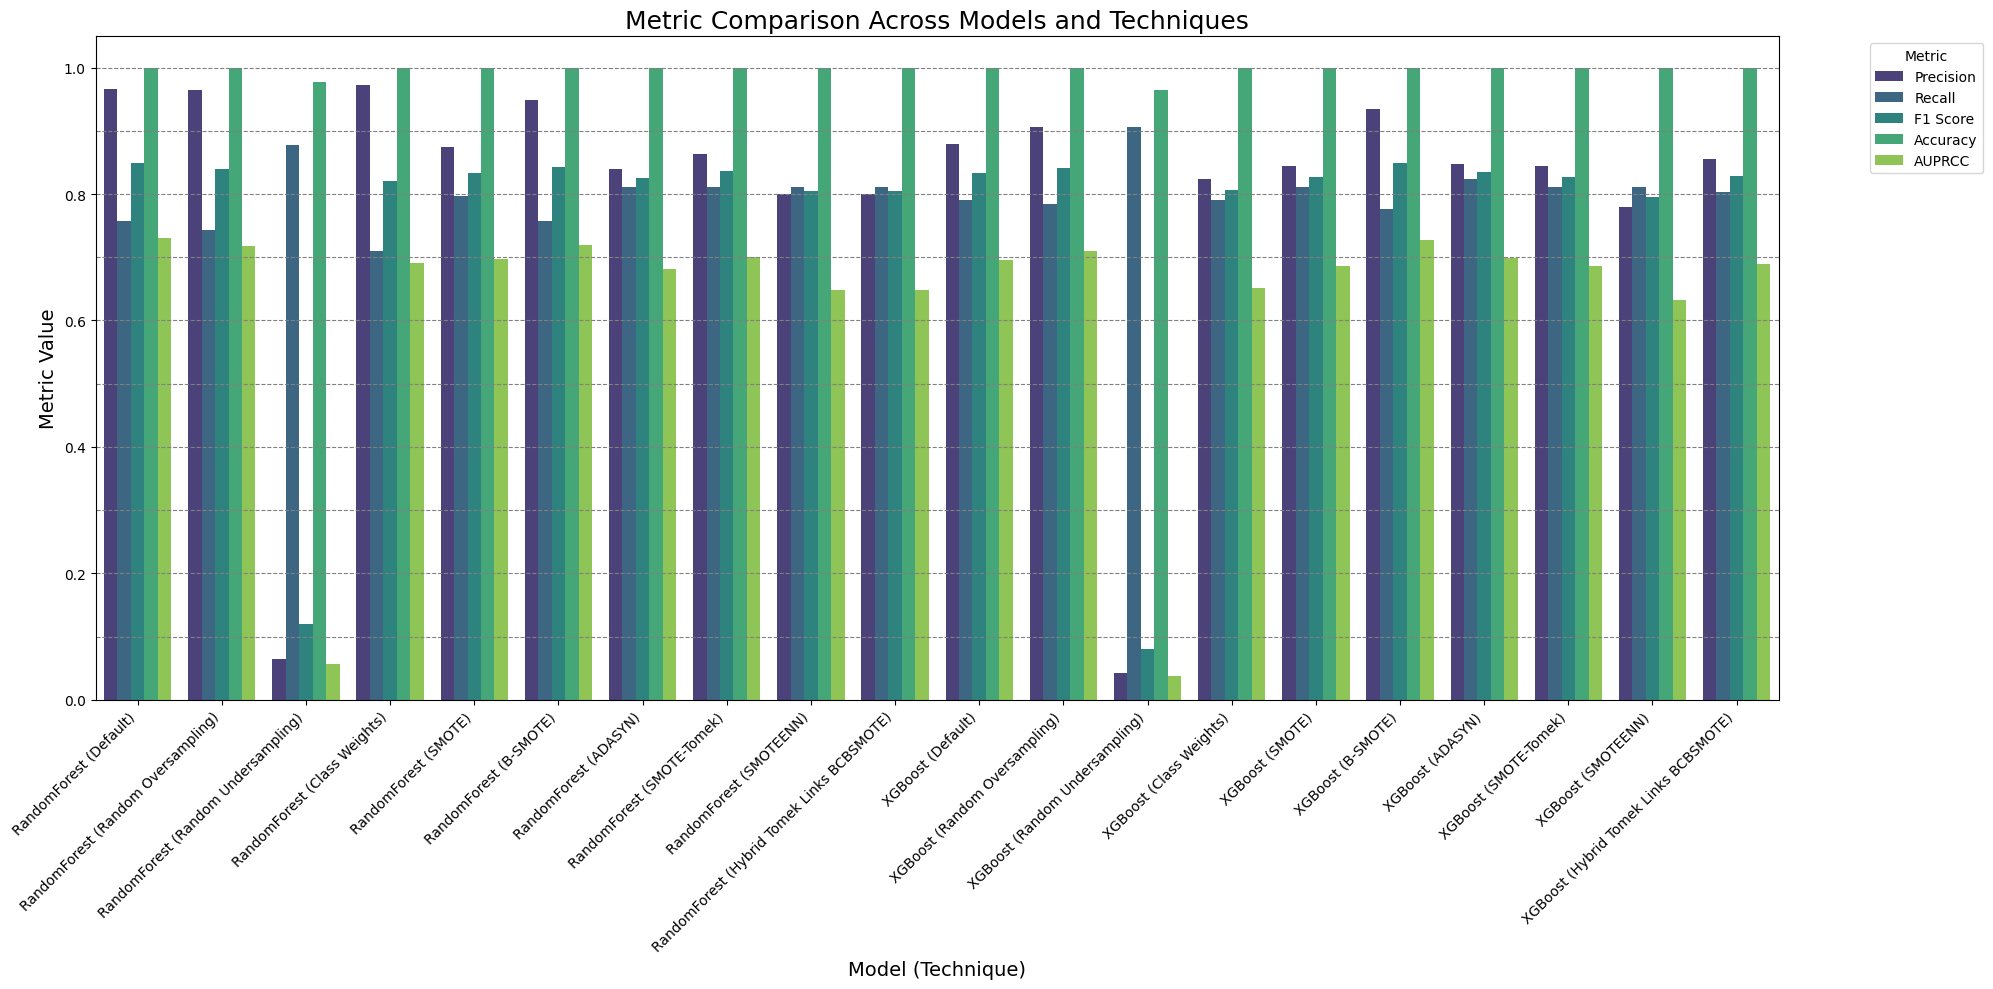

In [185]:
final_combined_df = pd.concat([combined_df_rf, combined_df_xgb], ignore_index=True)

final_combined_df['Model (Technique)'] = final_combined_df['Model'] + " (" + final_combined_df['Technique'] + ")"

long_format_df = final_combined_df.melt(
    id_vars=['Model (Technique)'], 
    value_vars=['Precision', 'Recall', 'F1 Score', 'Accuracy', 'AUPRCC'], 
    var_name='Metric',  
    value_name='Value' 
)

# Plot the bar chart
plt.figure(figsize=(20, 10))
sns.barplot(
    data=long_format_df,
    x='Model (Technique)', 
    y='Value', 
    hue='Metric', 
    palette='viridis', 
    errorbar=None
)

# Add horizontal lines
for y in range(1, 11):
    plt.axhline(y=y * 0.1, color='gray', linestyle='--', linewidth=0.8)

# Customize plot appearance
plt.title('Metric Comparison Across Models and Techniques', fontsize=18)
plt.xlabel('Model (Technique)', fontsize=14)
plt.ylabel('Metric Value', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [186]:
# Transforming the data to long format for multiple metrics
long_format_df = final_combined_df.melt(
    id_vars=['Technique', 'Model'], 
    value_vars=['Precision', 'Recall', 'F1 Score', 'Accuracy', 'AUPRCC'], 
    var_name='Metric', 
    value_name='Value'
)

# Create the interactive plot
fig = px.scatter(
    long_format_df, 
    x='Technique', 
    y='Value', 
    color='Model', 
    facet_col='Metric', 
    hover_data=['Value'], 
    title="Interactive Comparison: Techniques vs Models per Metric"
)

# Customize the layout for better clarity
fig.update_layout(
    xaxis_title="Technique",
    yaxis_title="Metrics Value",
    title_font_size=16,
    legend_title="Model",
    hovermode="closest"
)

fig.show()


![Interactive Plots](figures\interactive_plots.png)

### **Random Forest Analysis**

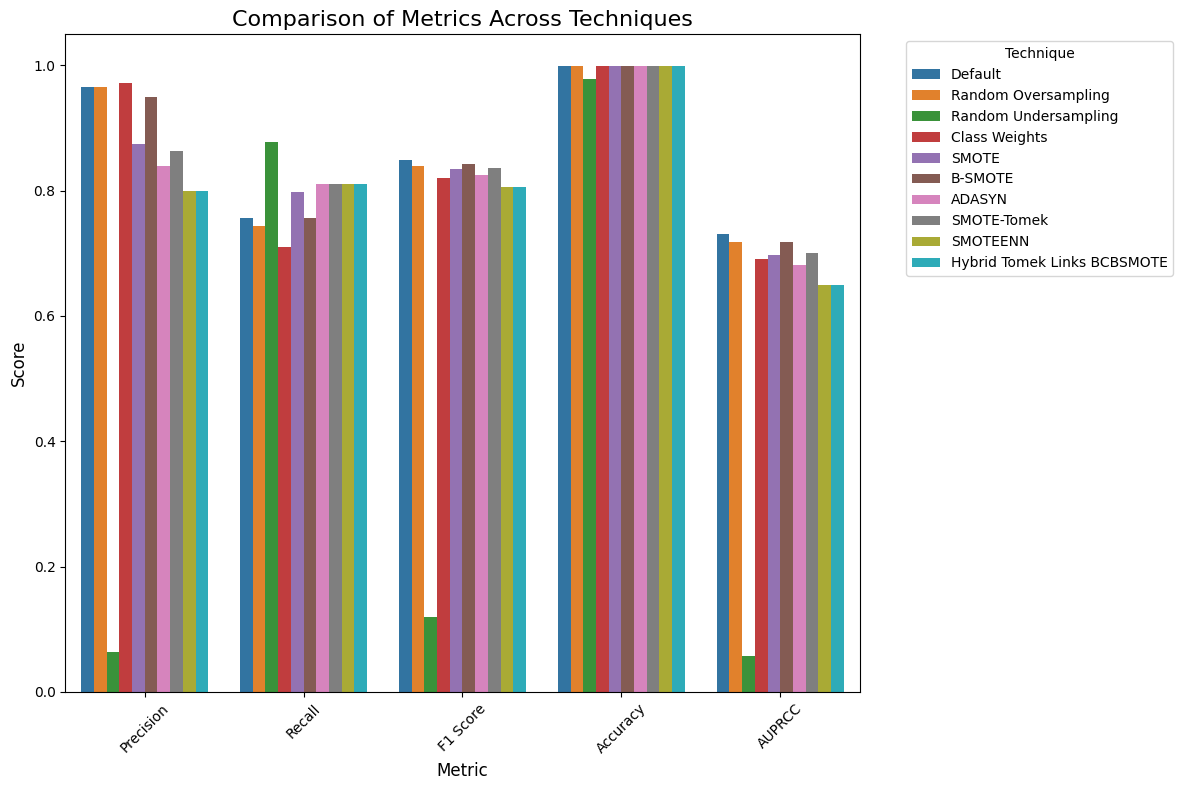

In [194]:
# Plotting the comparison of metrics across techniques
plt.figure(figsize=(12, 8))

melted_df = combined_df_rf.melt(id_vars=['Model', 'Technique'], 
                              value_vars=['Precision', 'Recall', 'F1 Score', 'Accuracy', 'AUPRCC'],
                              var_name='Metric', value_name='Value')

sns.barplot(data=melted_df, x='Metric', y='Value', hue='Technique')

plt.title('Comparison of Metrics Across Techniques', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Technique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

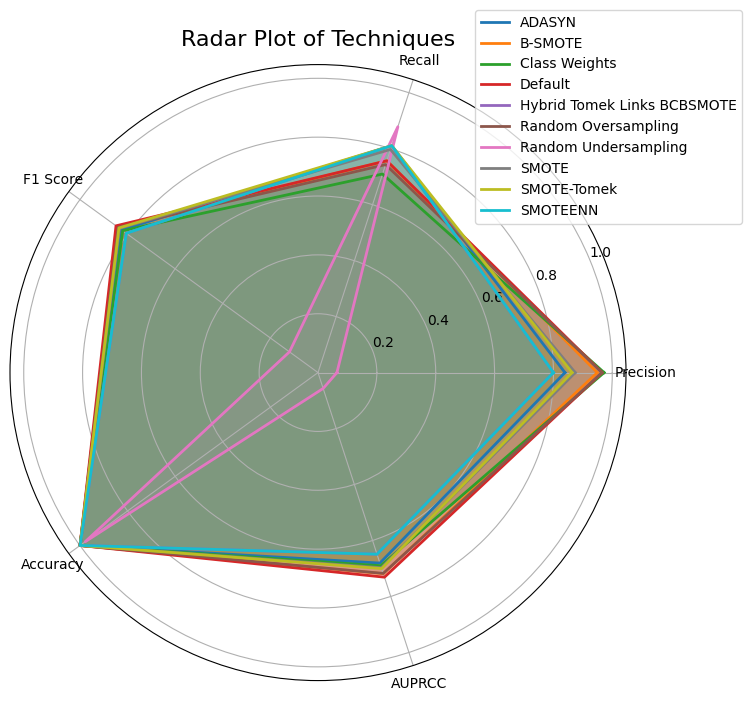

In [195]:
# Radar Plot
radar_data = combined_df_rf.groupby('Technique')[['Precision', 'Recall', 'F1 Score', 'Accuracy', 'AUPRCC']].mean()

radar_data.loc['close'] = radar_data.iloc[0]

labels = radar_data.columns
num_vars = len(labels)

angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1] 

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot
for technique in radar_data.index[:-1]: 
    values = radar_data.loc[technique].tolist()
    values += values[:1]  
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=technique)
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title('Radar Plot of Techniques', fontsize=16)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

The "Standard Random Forest" (without any balancing) performs well, but some balancing techniques, such as "B-SMOTE" and "Random Oversampling," improve Precision slightly. However, techniques like SMOTE and SMOTEENN have marginally lower Precision, indicating they might be introducing some noise. Balancing techniques generally improve Recall compared to the "Standard Random Forest," with methods like SMOTE, B-SMOTE, and ADASYN showing significant improvement, indicating better handling of the minority class.

In terms of the F1 Score, balancing techniques like B-SMOTE and Random Oversampling improve the score, suggesting they effectively balance Precision and Recall. Conversely, some techniques, such as SMOTEENN, perform worse than others, indicating trade-offs between Precision and Recall. Accuracy remains consistently high across all methods, including the "Standard Random Forest," which is expected in imbalanced datasets where the majority class dominates. However, accuracy alone is not a good indicator of performance for imbalanced datasets.

Regarding AUPRCC (Area Under the Precision-Recall Curve), the "Standard Random Forest" has the highest AUPRCC, but B-SMOTE, ADASYN, and SMOTE-Tomek are close. AUPRCC emphasizes performance on the minority class, and slight drops in this metric suggest trade-offs with balancing methods.

### **XGBoost Analysis**

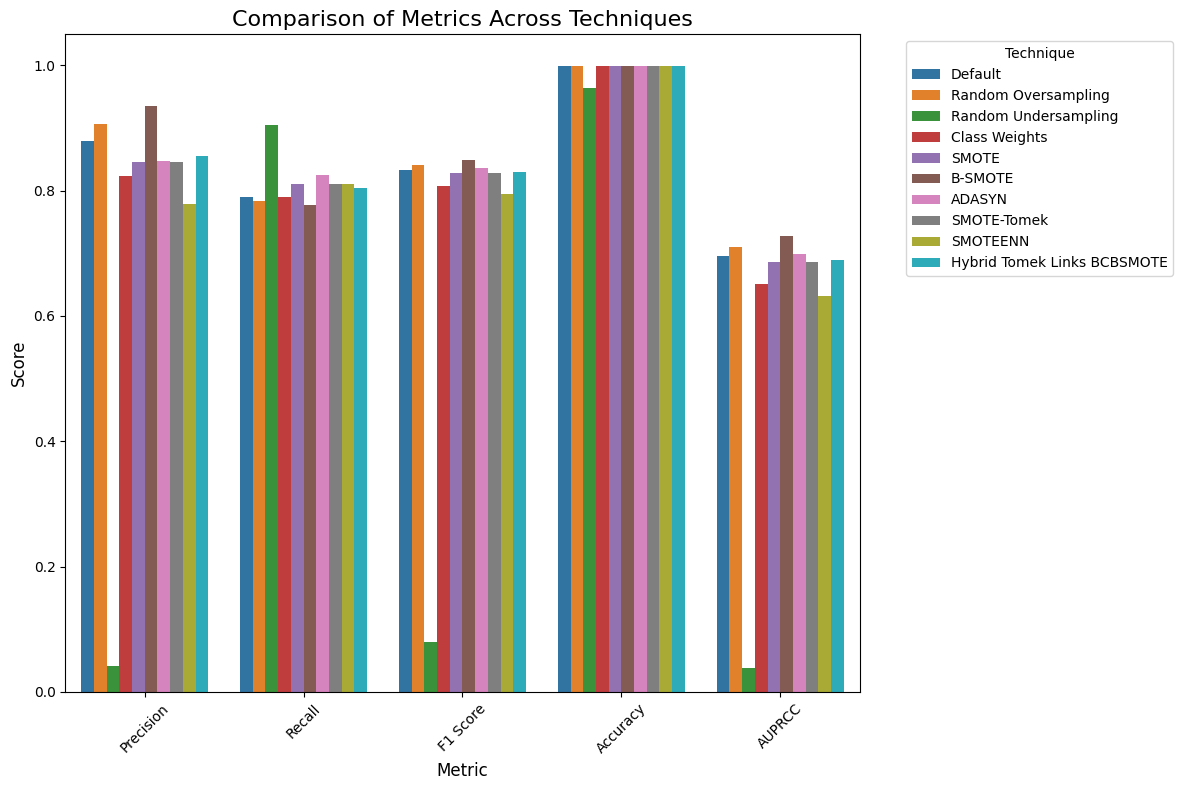

In [196]:
# Plotting the comparison of metrics across techniques
plt.figure(figsize=(12, 8))

melted_df = combined_df_xgb.melt(id_vars=['Model', 'Technique'], 
                              value_vars=['Precision', 'Recall', 'F1 Score', 'Accuracy', 'AUPRCC'],
                              var_name='Metric', value_name='Value')

sns.barplot(data=melted_df, x='Metric', y='Value', hue='Technique')

plt.title('Comparison of Metrics Across Techniques', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Technique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

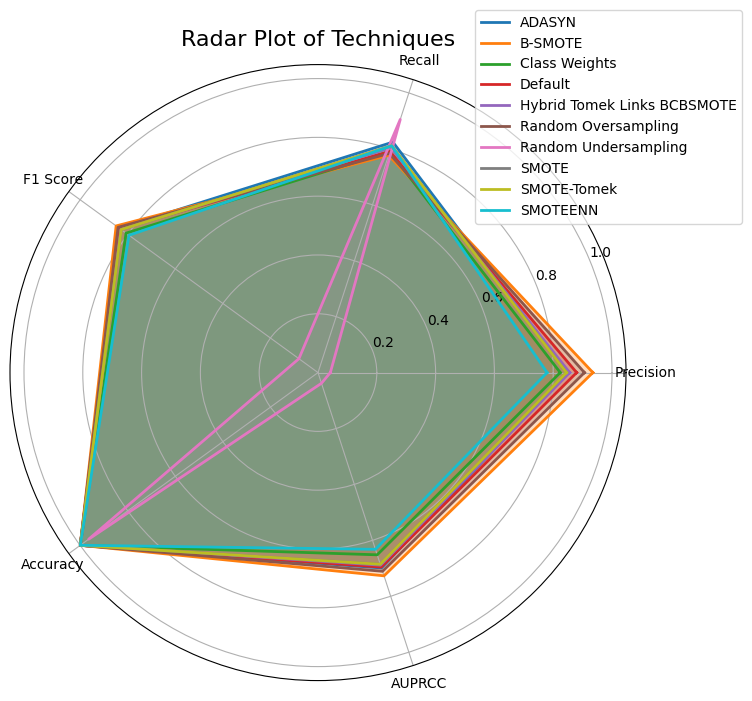

In [197]:
# Radar Plot
radar_data = combined_df_xgb.groupby('Technique')[['Precision', 'Recall', 'F1 Score', 'Accuracy', 'AUPRCC']].mean()

radar_data.loc['close'] = radar_data.iloc[0]

labels = radar_data.columns
num_vars = len(labels)

angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1] 

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for technique in radar_data.index[:-1]: 
    values = radar_data.loc[technique].tolist()
    values += values[:1] 
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=technique)
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title('Radar Plot of Techniques', fontsize=16)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

XGBoost exhibits consistently high Precision across techniques, with methods like Random Oversampling and B-SMOTE marginally enhancing Precision compared to the Standard Random Forest baseline. In terms of Recall, XGBoost benefits significantly from balancing techniques, with methods such as SMOTE, SMOTEENN, and B-SMOTE yielding noticeable gains. These techniques are particularly valuable for imbalanced datasets, and additional balancing techniques like Hybrid Tomek Links BCBSMOTE seem to maintain a competitive edge.

The F1 Score reflects the trade-off between Precision and Recall, and techniques such as ADASYN, SMOTE, and B-SMOTE perform well in achieving a balance, with SMOTEENN also showing promising results. The Accuracy metric remains consistently very high, showing minimal variation across techniques. This suggests that for XGBoost, Accuracy alone may not fully reflect the effectiveness of balancing techniques, as it tends to remain robust even without heavy class balancing.

Regarding AUPRCC (Area Under Precision-Recall Curve), this metric provides insight into model performance for imbalanced datasets. Techniques like B-SMOTE, SMOTE, and Random Oversampling clearly boost AUPRCC, while SMOTEENN lags slightly. This indicates that these techniques better handle the minority class for XGBoost.

### **Best Models Comparison**

In [198]:
def plot_confusion_matrix(cm, title='Confusion Matrix', labels=['Non-Fraud', 'Fraud']):
    """
    Plots a confusion matrix with all values (including the two bottom values for fraud cases).
    """
    
    TN, FP, FN, TP = np.array(cm).ravel()

    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False, linewidths=1, linecolor='black')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    plt.title(title, fontsize=14)

    plt.figtext(0.15, -0.05, f"True Negatives (TN): {TN}, False Positives (FP): {FP}", fontsize=10, ha="left")
    plt.figtext(0.15, -0.10, f"False Negatives (FN): {FN}, True Positives (TP): {TP}", fontsize=10, ha="left")

    plt.tight_layout()
    plt.show()

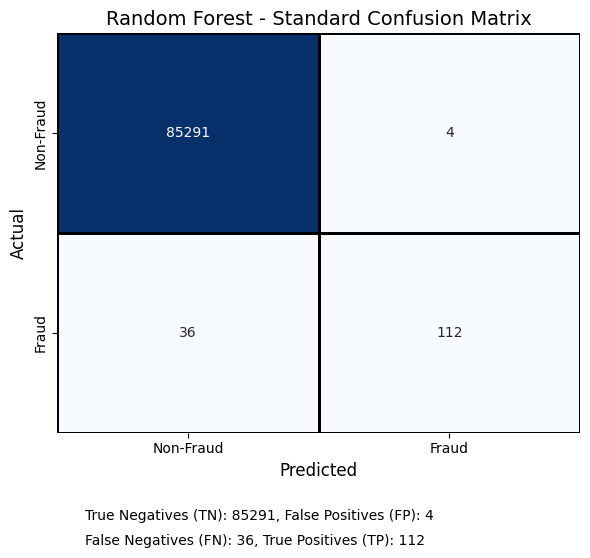

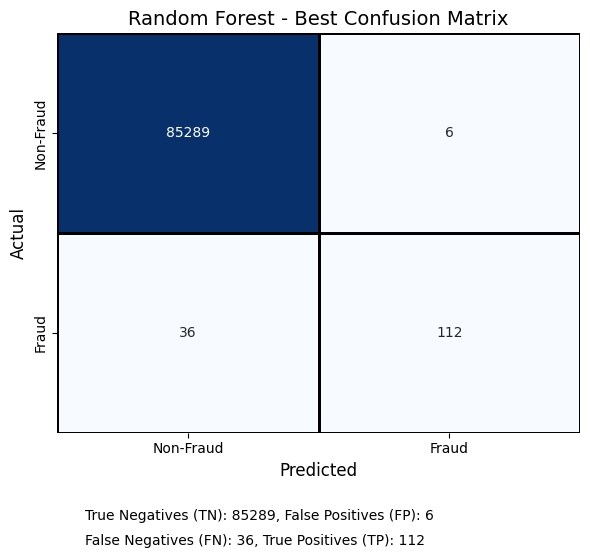

In [199]:
plot_confusion_matrix(cm_standard_rf, title='Random Forest - Standard Confusion Matrix')
plot_confusion_matrix(cm_bsmote_rf, title='Random Forest - Best Confusion Matrix')

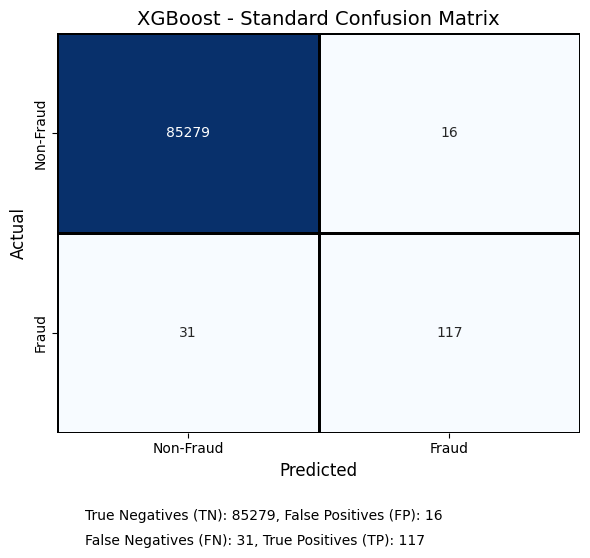

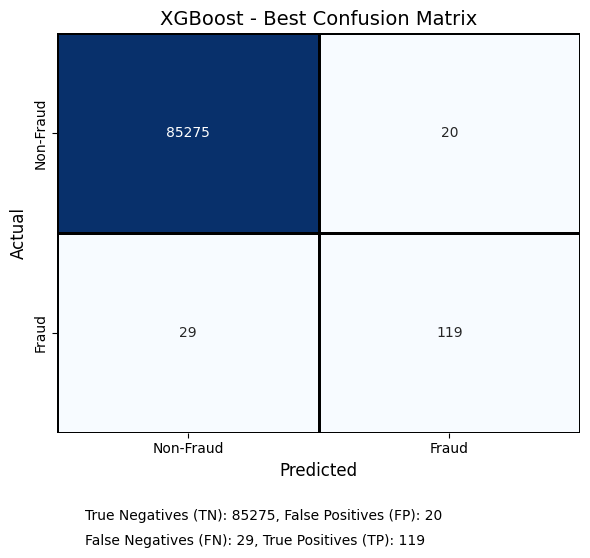

In [200]:
plot_confusion_matrix(cm_standard_xgb, title='XGBoost - Standard Confusion Matrix')
plot_confusion_matrix(cm_bcbsmote_xgb, title='XGBoost - Best Confusion Matrix')

### **Key Takeaways**

Balancing techniques, such as SMOTE, B-SMOTE, and Random Oversampling, are consistently effective in improving model performance across algorithms like Random Forest and XGBoost, particularly in addressing imbalanced datasets. These methods enhance critical metrics like Recall and F1 Score, showcasing their ability to reduce false negatives while maintaining competitive Precision. However, there is an inherent trade-off between Precision and Recall, as balancing often leads to slight decreases in Precision. This trade-off is significant depending on whether false positives or false negatives are prioritized.

SMOTEENN, while effective in boosting Recall and Precision in some cases, tends to underperform in metrics like AUPRCC, possibly due to over-cleaning or introducing noise during balancing. The performance of balancing techniques like B-SMOTE and Random Oversampling demonstrates their versatility and reliability across both algorithms, with Random Forest and XGBoost benefiting from these methods. Moreover, the high accuracy observed for all techniques highlights its inadequacy as the sole metric for evaluating imbalanced datasets. Metrics such as F1 Score, Recall, and AUPRCC provide a more nuanced understanding of model performance and should be prioritized in such scenarios.

## **Conclusion**

This case study explores the challenge of handling imbalanced datasets, using the [Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download) as a representative example, and examines the impact of various balancing techniques on the performance of machine learning algorithms. By employing Random Forest and XGBoost as the primary models, the study evaluates the effectiveness of these techniques in improving classification performance across key metrics such as Precision, Recall, F1 Score, Accuracy, and AUPRCC.

**Key Findings:**

1. **Imbalance Challenges and Metric Selection**:  
   The severe class imbalance in the dataset (fraudulent transactions making up only 0.17% of the total) emphasizes the inadequacy of accuracy as a sole evaluation metric. Despite both algorithms achieving high accuracy across all experiments, metrics like Recall, F1 Score, and AUPRCC proved more insightful in assessing performance, particularly for the minority class. This reinforces the importance of using metrics tailored to the needs of imbalanced datasets.

2. **Baseline Performance**:  
   Without balancing techniques, both Random Forest and XGBoost exhibited strong Precision but struggled with Recall, leading to suboptimal F1 Scores. This highlights a common issue in imbalanced datasets, where models prioritize the majority class, often at the expense of identifying minority class instances (fraudulent transactions in this case).

3. **Impact of Balancing Techniques**:  
   Incorporating balancing techniques such as Random Oversampling, SMOTE, B-SMOTE, ADASYN, SMOTE-Tomek, SMOTEENN, and Hybrid Tomek Links BCBSMOTE substantially improved Recall and F1 Score for both algorithms, addressing the minority class bias. However, there was a trade-off with Precision, as balancing techniques occasionally introduced false positives by over-representing the minority class.  
   - **Random Oversampling** and **B-SMOTE** consistently delivered a good balance across all metrics, making them reliable choices for both Random Forest and XGBoost.  
   - **SMOTEENN**, while improving Recall, struggled with AUPRCC, likely due to over-cleaning or noise introduced during the resampling process, particularly in extreme imbalance scenarios.

4. **Algorithm-Specific Observations**:  
   - **Random Forest** showed robust performance gains from balancing techniques, particularly benefiting from methods like Random Oversampling, SMOTE, and ADASYN. The improvements were most notable in Recall and F1 Score, making it a strong contender for fraud detection in imbalanced datasets.  
   - **XGBoost**, a gradient boosting method, demonstrated consistent performance across all balancing techniques, with strong improvements in Recall, Precision, and F1 Score. This highlights its ability to adapt to resampled datasets effectively. Notably, SMOTEENN's underperformance in AUPRCC was more apparent with XGBoost.

5. **Trade-offs and Practical Implications**:  
   The trade-off between Precision and Recall underscores the importance of aligning model evaluation with the specific needs of the application. For example, in fraud detection, prioritizing Recall to minimize false negatives (missed fraud cases) may be more critical, even at the cost of slightly reduced Precision. Balancing techniques like B-SMOTE and Random Oversampling offer a promising compromise, improving overall detection rates without excessively inflating false positives.

**Conclusion**:  
Balancing techniques significantly enhance the effectiveness of machine learning models in tackling imbalanced datasets, as evidenced by the improvements in Recall, F1 Score, and AUPRCC for both Random Forest and XGBoost. These results reaffirm the importance of carefully selecting and tuning resampling methods based on the dataset and the business context. While balancing techniques address the bias toward the majority class, they introduce trade-offs that must be managed to ensure optimal model performance.

This study underscores the need for a metric-driven approach to evaluate models on imbalanced datasets and demonstrates that combining robust algorithms like Random Forest and XGBoost with effective balancing techniques can yield powerful solutions for fraud detection and other imbalanced classification tasks.

## **Bibliography**

**https://www.researchgate.net/publication/377619332_Hybrid_Undersampling_and_Oversampling_for_Handling_Imbalanced_Credit_Card_Data**

(Adicionar mais referências)

Apontamentos Professora:

- dataprep para data profiling - o código já está, mas não consigo instalar

- problexity para fazer plot com medidas de complexidade
- perceber com base nas medidas do dataset se faz sentido (a nossa melhor) ser o melhor 
- perceber se operaçao de limpeza ajudou (após limpeza , antes do smote)

- isa para original e isa para smote - seguir o que está no notebook 2 da professora